# SED anatomy — a kitchen-sink galaxy from X-rays to radio

A faithful SED is a *composition*: stellar continuum, nebular emission,
dust attenuation and re-emission, AGN, radio, X-ray, and intergalactic
absorption. Tengri composes all of this from one nested-dict specification.

The figure below is a **kitchen-sink** model at z = 2 — every component
turned on — followed by four mini-sweeps that isolate a single knob
at a time. The notebook closes with a complete self-consistent SED from
hard X-rays to the radio, with every block overlaid on the total.

As the model is built, notice:

- `model.summary()` makes the assembly explicit.
- `citations.print_citations(model)` produces a working bibliography
  for the methods section.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # silence XLA/PjRt C++ INFO+WARNING logs

import logging
import warnings
from copy import deepcopy
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

# Keep the narrative clean: hide JAX/XLA chatter, the harmless
# BakedInBackend notice (emitted when a component has no precompute
# path), and the SFH-before-Big-Bang notice the z = 2 demo triggers
# (a parametric SFH there has support older than cosmic time; the
# absolute mass scale is irrelevant for the shape-only anatomy figure).
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.getLogger("jax").setLevel(logging.ERROR)

from _setup import FIG_DIR
import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    builders,
    citations,
    plot,
    recipes,
)
from tengri.units import erg_per_s_to_lsun, lnu_to_llambda

plot.setup_style()

## Setup — bare-stellar SSP and panchromatic filters

Cue needs a bare-stellar SSP. The filter set spans GALEX through ALMA
so every component has somewhere to be visible.

In [2]:
ssp = tengri.load_ssp("fsps_prsc_miles_chabrier", download=True)

filters = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "ukidss_y",
    "ukidss_j",
    "ukidss_h",
    "ukidss_k",
    "irac_36",
    "irac_45",
    "irac_58",
    "irac_80",
    "wise_w3",
    "wise_w4",
    "mips_24",
    "mips_70",
    "mips_160",
    "herschel_100",
    "herschel_160",
    "herschel_250",
    "herschel_350",
    "herschel_500",
]
obs = Observation(photometry=Photometry.from_names(filters))

## The kitchen-sink model

A complete model at z = 2 with all major components enabled: star formation,
dust attenuation and emission, nebular continuum and lines, AGN, radio, X-ray,
and intergalactic absorption. Every parameter pinned at a physically reasonable
value so the figure is reproducible.

In [3]:
# ``log_lbol`` is log10(L_bol / Lsun) — set the disc to a modest AGN.
# At z = 2 (cosmic age 3.29 Gyr) a parametric DPL inevitably has some
# support before the Big Bang, which tengri flags with an
# ``SFHBeforeBigBangWarning`` and truncates; the absolute mass scale is
# irrelevant for this shape-only anatomy figure, so we silence it above.
kitchen_sink = dict(
    sfh={
        "type": "dpl",
        "all_params": FIXED,
        "log_total_mass": 10.5,
        "alpha": 2.2,
        "beta": 1.4,
        "tau_gyr": 4.0,
    },
    dust_attenuation={
        "type": "two_component",
        "law": "calzetti",
        "all_params": FIXED,
        "tau_bc": 0.8,
        "tau_diff": 0.3,
        "slope": -0.4,
        # dale2014_cigale, not dale2014: this notebook also switches on a radio
        # block, and the plain Dale+2014 template embeds its own star-forming
        # radio synchrotron continuum out to 1.335 GHz. Running both double-counts
        # the radio continuum (~2x between ~1.34 and ~10 GHz), which #1983 made a
        # ConfigError. The _cigale variant has that tail stripped, per CIGALE
        # convention — the remedy that error itself prescribes.
    }, dust_emission={"type": "dale2014_cigale", "all_params": FIXED, "alpha_dale": 2.2},
    neb={"type": "cue", "all_params": FIXED},
    agn={
        "all_params": FIXED,  # every AGN block here is deliberately fixed (#1995)
        "disc": {"type": "multicolor", "all_params": FIXED, "log_lbol": 10.5},
        "torus": {"type": "skirtor", "all_params": FIXED, "tau_skirtor": 5.0, "torus_frac": 0.5},
        "nlr": {"type": "analytic", "all_params": FIXED},
        "blr": {"type": "none", "all_params": FIXED},
    },
    radio={"sf": {"type": "bell2003"}, "agn": {"type": "powerlaw"}, "all_params": FIXED},
    xray={"type": "simple", "all_params": FIXED},
    redshift=Fixed(2.0),
    igm={"type": "inoue"},
)

model = SEDModel.build(ssp_data=ssp, observation=obs, **kitchen_sink)
print(model.summary())

Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     25 bands
  Redshift:    2.0000 (fixed)
  Dtype:       float64
  Fast path:   exact (approx=None)
  Components:  nebular=cue, dust_emission=dale2014_cigale, agn=composable, igm, radio, xray

  Pipeline (8 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=cue]
    3. dust           [law=calzetti]
    4. dust_emission
    5. agn            [model=composable]
    6. radio
    7. xray           [model=simple]
    8. igm

  Parameters:  0 free
──────────────────────────────────────────────────────────────────


## Citations from the assembled model

In [4]:
citations.print_citations(model)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Oke \& Gunn (1983)  —  AB magnitude system / absolute spectrophotometric zero point
       {Secondary standard stars for absolute spectrophotometry.}
       DOI: 10.1086/160817

  [5] Hogg et al. (2002)  —  Photon-counting bandpass AB flux (Eq.~5); K-correction formalism
       {The K correction}

## Hero figure — the panchromatic anatomy

All components of the SED from X-rays to the radio, shown together on a
single rest-frame wavelength grid.

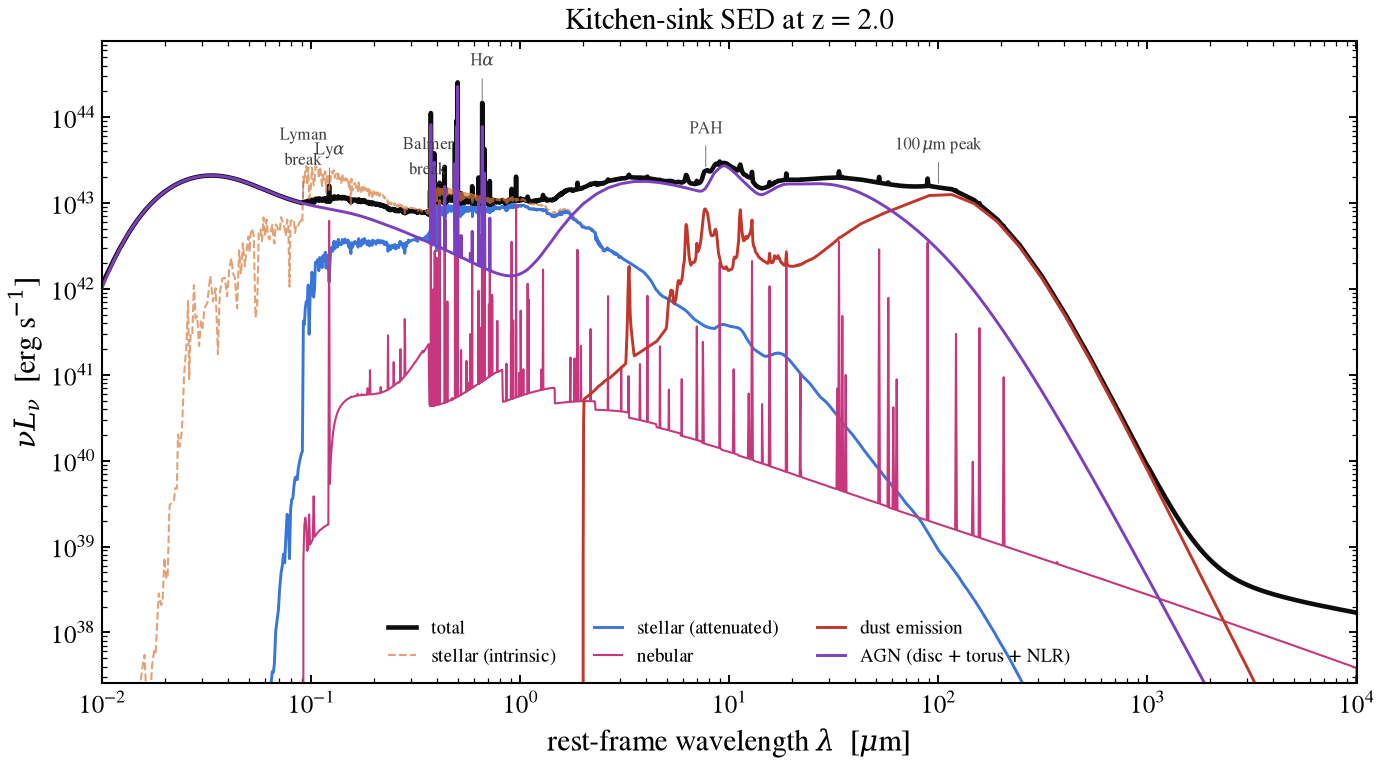

In [5]:
params = model.spec.sample(jax.random.PRNGKey(0))
state = model.predict_state(params)

wave_rest = np.asarray(state.wave)  # Å
total = np.asarray(state.sed_intrinsic)  # erg/s/Hz, post-dust-attenuation + emission


# Per-component contributions from the orchestrator's derived bundle.
def _get(key, default=None):
    arr = state.derived.get(key, default)
    return None if arr is None else np.asarray(arr)


lnu_age = _get("lnu_age")  # (n_age, n_wave) intrinsic
sed_stellar_intrinsic = lnu_age.sum(axis=0) if lnu_age is not None else None
sed_stellar_attenuated = _get("sed_dust_attenuated")
sed_nebular = _get("sed_nebular")
sed_dust_emission = _get("sed_dust_ir")
sed_agn = _get("sed_agn", _get("sed_grahsp"))  # AGN may be off in some builds

C = {
    "stellar": "#d97a3a",  # warm
    "nebular": "#c8377d",  # magenta
    "dust_att": "#3a76d9",  # blue
    "dust_em": "#c3372a",  # red
    "agn": "#7c3fbf",  # violet
    "total": "0.05",  # near-black
}

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"rest-frame wavelength $\lambda$  [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$  [erg s$^{-1}$]")
wave_um = wave_rest / 1e4


def nu_lnu(wave, lnu):
    """nu*L_nu [erg/s] on a wavelength grid [Angstrom].

    nu*L_nu and lambda*L_lambda are the same quantity, so the public unit
    conversion gives it without hand-rolling a speed-of-light literal.
    """
    return None if lnu is None else wave * lnu_to_llambda(lnu, wave)


def nuLnu(y):
    return nu_lnu(wave_rest, y)


ax.plot(wave_um, nuLnu(total), color=C["total"], lw=2.2, label="total")
if sed_stellar_intrinsic is not None:
    ax.plot(
        wave_um,
        nuLnu(sed_stellar_intrinsic),
        color=C["stellar"],
        lw=1.0,
        ls="--",
        alpha=0.7,
        label="stellar (intrinsic)",
    )
if sed_stellar_attenuated is not None:
    ax.plot(
        wave_um,
        nuLnu(sed_stellar_attenuated),
        color=C["dust_att"],
        lw=1.4,
        label="stellar (attenuated)",
    )
if sed_nebular is not None:
    ax.plot(wave_um, nuLnu(sed_nebular), color=C["nebular"], lw=1.0, label="nebular")
if sed_dust_emission is not None:
    ax.plot(wave_um, nuLnu(sed_dust_emission), color=C["dust_em"], lw=1.4, label="dust emission")
if sed_agn is not None:
    ax.plot(wave_um, nuLnu(sed_agn), color=C["agn"], lw=1.4, label="AGN (disc + torus + NLR)")

# Annotate physical features.
for lam_um, label in [
    (0.0912, "Lyman\nbreak"),
    (0.122, r"Ly$\alpha$"),
    (0.36, "Balmer\nbreak"),
    (0.6564, r"H$\alpha$"),
    (7.7, "PAH"),
    (100, r"100$\,\mu$m peak"),
]:
    if lam_um < wave_um.min() or lam_um > wave_um.max():
        continue
    y = np.interp(lam_um, wave_um, nuLnu(total))
    ax.annotate(
        label,
        xy=(lam_um, y),
        xytext=(0, 18),
        textcoords="offset points",
        fontsize=8,
        ha="center",
        color="0.25",
        arrowprops=dict(arrowstyle="-", color="0.5", lw=0.5),
    )

ax.set_xlim(1e-2, 1e4)
ax.set_ylim(nuLnu(total).max() * 1e-7, nuLnu(total).max() * 3)
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=9)
ax.set_title(f"Kitchen-sink SED at z = {float(params['redshift']):.1f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_anatomy_panchromatic.png", dpi=300, bbox_inches="tight")

## Four sweeps, one knob at a time

All on a leaner star-forming recipe so the figures stay readable;
everything is held fixed except the swept parameter.

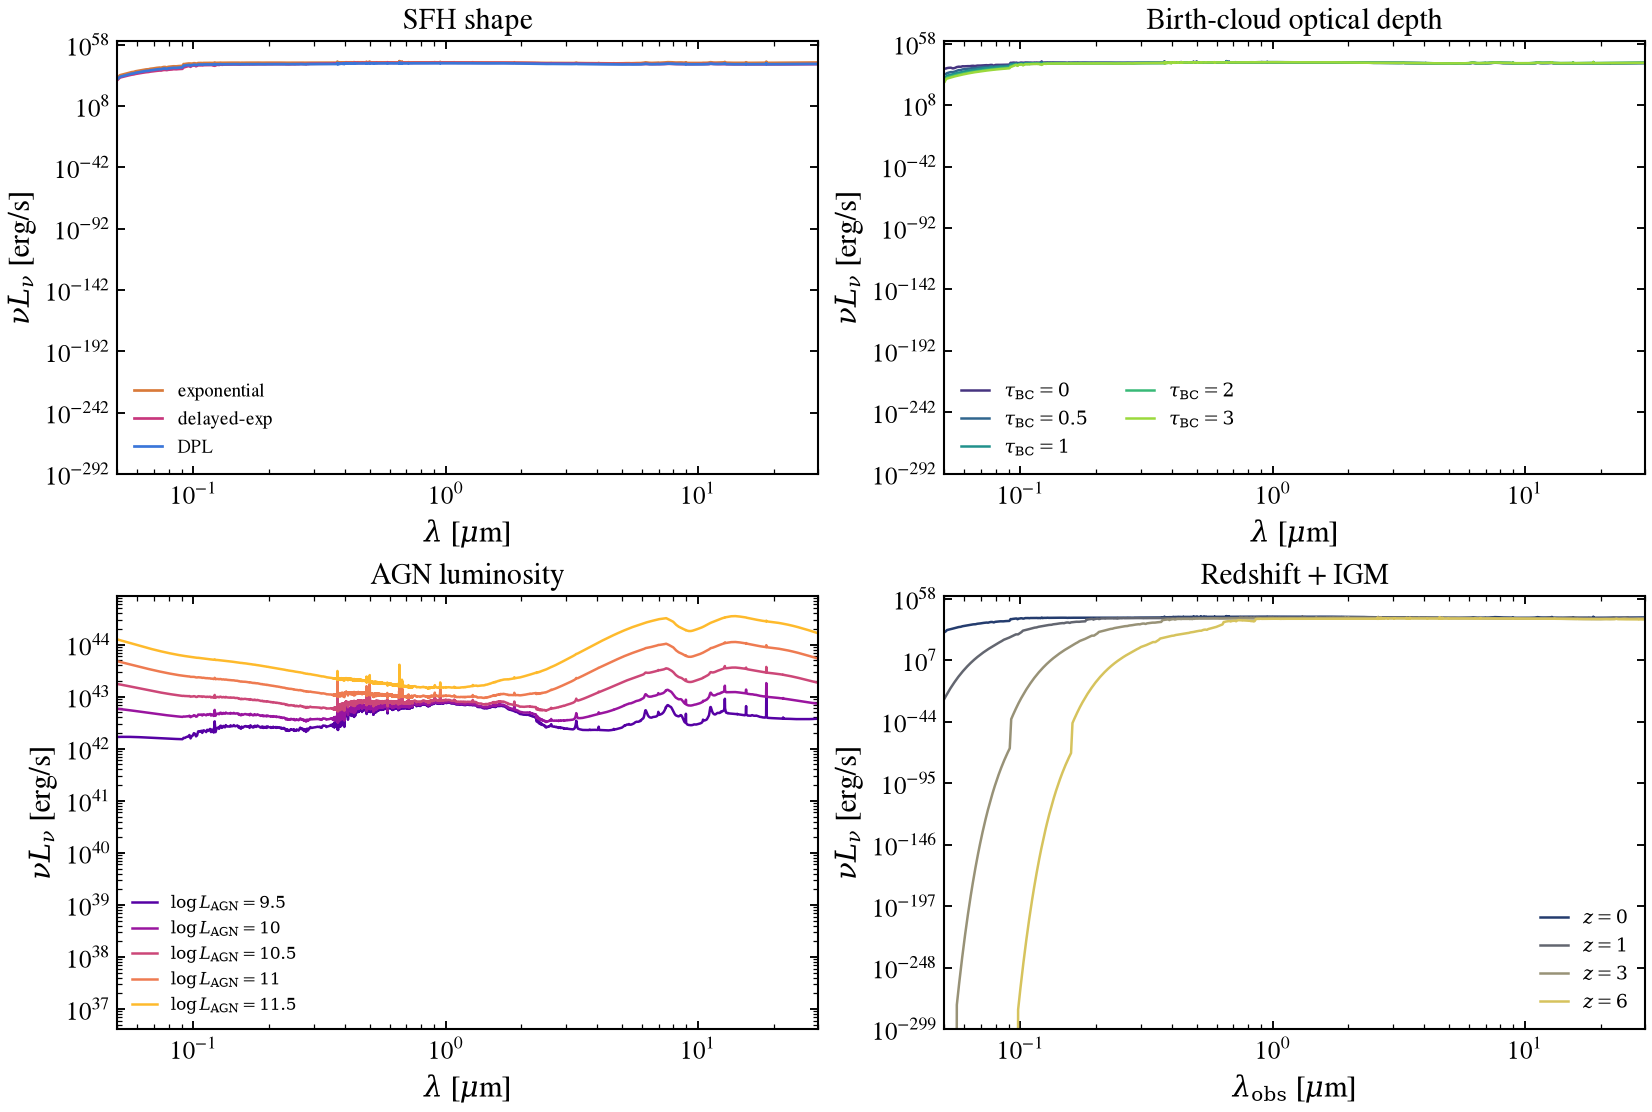

In [6]:
base = recipes.star_forming_photometry()
# Pin the model down to defaults, then sweep one parameter at a time.
base["sfh"]["all_params"] = FIXED
base["dust_attenuation"]["all_params"] = FIXED
base["dust_emission"]["all_params"] = FIXED
base["redshift"] = Fixed(0.5)


def predict_rest(m, p):
    s = m.predict_state(p)
    return np.asarray(s.wave), np.asarray(s.sed_intrinsic)


fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), constrained_layout=True)


# (a) SFH shape — three canonical SFHs, mass-normalized
ax = axes[0, 0]
for label, sfh_dict, color in [
    ("exponential", builders.sfh.exp(all_params=FIXED), "#d97a3a"),
    ("delayed-exp", builders.sfh.dexp(all_params=FIXED), "#c8377d"),
    ("DPL", builders.sfh.dpl(all_params=FIXED), "#3a76d9"),
]:
    cfg = deepcopy(base)
    cfg["sfh"] = sfh_dict
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    w, sed = predict_rest(m, p)
    ax.plot(w / 1e4, nu_lnu(w, sed), label=label, color=color, lw=1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("SFH shape")
ax.legend(frameon=False, fontsize=9)

# (b) Birth-cloud τ_V sweep — same structure, varying parameter value
# Build once with tau_bc as a free parameter; predict at each value.
# This teaches that a model is a function of its parameters: same structure, many parameter values.
ax = axes[0, 1]
cmap = plt.colormaps["viridis"]
tau_grid = [0.0, 0.5, 1.0, 2.0, 3.0]
cfg = deepcopy(base)
cfg["dust_attenuation"]["tau_bc"] = Uniform(0.0, 3.0)  # tau_bc is now a free parameter
m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
p = m.spec.sample(jax.random.PRNGKey(0))
for tau, col in zip(tau_grid, cmap(np.linspace(0.15, 0.85, len(tau_grid)))):
    w, sed = predict_rest(m, {**p, "dust_tau_bc": tau})
    ax.plot(w / 1e4, nu_lnu(w, sed), color=col, lw=1.2, label=rf"$\tau_{{\rm BC}}={tau:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("Birth-cloud optical depth")
ax.legend(frameon=False, fontsize=9, ncol=2)

# (c) AGN bolometric luminosity sweep — same structure, varying parameter value
# Lightweight AGN (multicolor disc + Nenkova torus): build once, predict at each luminosity.
# The Nenkova torus is a cheap analytic stand-in (SKIRTOR would cost 5×).
# ``log_lbol`` is log10(L_bol / Lsun), so 10–11 spans a Seyfert to a low-luminosity quasar.
ax = axes[1, 0]
log_lbol_grid = [9.5, 10.0, 10.5, 11.0, 11.5]
cmap = plt.colormaps["plasma"]
cfg = deepcopy(base)
cfg["agn"] = {
    "all_params": FIXED,  # unprovided sub-blocks (nlr/blr/feii/atten) stay fixed by intent
    "disc": {"type": "multicolor", "all_params": FIXED, "log_lbol": Uniform(9.0, 12.0)},
    "torus": {"type": "nenkova", "all_params": FIXED},
}
m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
p = m.spec.sample(jax.random.PRNGKey(0))
for log_lbol, col in zip(log_lbol_grid, cmap(np.linspace(0.15, 0.85, len(log_lbol_grid)))):
    w, sed = predict_rest(m, {**p, "agn_log_lbol": log_lbol})
    ax.plot(
        w / 1e4, nu_lnu(w, sed), color=col, lw=1.2, label=rf"$\log L_{{\rm AGN}}={log_lbol:g}$"
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("AGN luminosity")
ax.legend(frameon=False, fontsize=8, ncol=1)

# (d) Redshift sweep — same intrinsic, different IGM + observed-frame
ax = axes[1, 1]
z_grid = [0.0, 1.0, 3.0, 6.0]
cmap = plt.colormaps["cividis"]
for z, col in zip(z_grid, cmap(np.linspace(0.15, 0.85, len(z_grid)))):
    cfg = deepcopy(base)
    cfg["redshift"] = Fixed(z)
    cfg["igm"] = {"type": "inoue"} if z > 0 else {"type": "none"}
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    pred = m.predict(p)
    w_obs = np.asarray(pred.wave_obs)  # observed-frame wavelength [Å]
    sed_obs = np.asarray(pred.obs_sed())  # L_nu [erg/s/Hz], observed frame + IGM
    ax.plot(w_obs / 1e4, nu_lnu(w_obs, sed_obs), color=col, lw=1.2, label=rf"$z={z:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda_{\rm obs}$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("Redshift + IGM")
ax.legend(frameon=False, fontsize=9)

fig.savefig(FIG_DIR / "02_anatomy_sweeps.png", dpi=300, bbox_inches="tight")

## Editing a built model — `spec.to_groups()`

Pull the model's configuration back, edit a parameter, and rebuild:

In [7]:
groups = model.spec.to_groups()
groups["dust_attenuation"]["tau_bc"] = Fixed(1.5)  # double the birth-cloud opacity
model_edited = SEDModel.build(ssp_data=ssp, observation=obs, **groups)
print(model_edited.summary())

Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     25 bands
  Redshift:    2.0000 (fixed)
  Dtype:       float64
  Fast path:   exact (approx=None)
  Components:  nebular=cue, dust_emission=dale2014_cigale, agn=composable, igm, radio, xray

  Pipeline (8 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=cue]
    3. dust           [law=calzetti]
    4. dust_emission
    5. agn            [model=composable]
    6. radio
    7. xray           [model=simple]
    8. igm

  Parameters:  0 free
──────────────────────────────────────────────────────────────────


## What each layer does, in one sentence

- **Stellar continuum.** DSPS-driven SSP integration: an SFH +
  metallicity history projects onto an age × wavelength grid and sums
  to the intrinsic L_ν.
- **Dust attenuation.** Birth-cloud (Calzetti) and diffuse-ISM optical
  depths reshape the UV–NIR. Energy absorbed is bookkept as `L_ir`.
- **Dust emission.** Dale 2014 / Draine–Li / THEMIS templates
  re-radiate `L_ir` from 8 to 1000 µm.
- **Nebular.** Cue (neural emulator on Cloudy 17.03) gives photoionized
  continuum + 128 emission lines from `nion` and ionization conditions.
- **AGN.** Disc (multicolor / Kubota–Done / ADAF / power-law) +
  torus (SKIRTOR / Nenkova / CAT3D / Silva04 / toy) + NLR (Cue) +
  BLR (qsogen).
- **Radio.** Free-free + synchrotron from the IR–radio correlation
  plus an AGN power-law if a disc is present.
- **X-ray.** Lusso & Risaliti 2017 L_2500 → L_2keV with optional
  ADAF / Comptonization refinements.
- **IGM.** Inoue 2014 Lyman-alpha forest opacity at z > 0.

## The money shot — one model, X-rays to radio

A complete self-consistent SED from hard X-rays to the radio at z = 0.1.
The model parameters (M_star, SFR, and AGN bolometric luminosity) are
displayed in the title, read from the assembled model.

The X-ray component is shown twice: unobscured and behind a heavily-absorbing
column (N_H = 10²³ cm⁻²) to demonstrate how line-of-sight photoelectric
absorption carves the soft band while hard X-rays pass through.

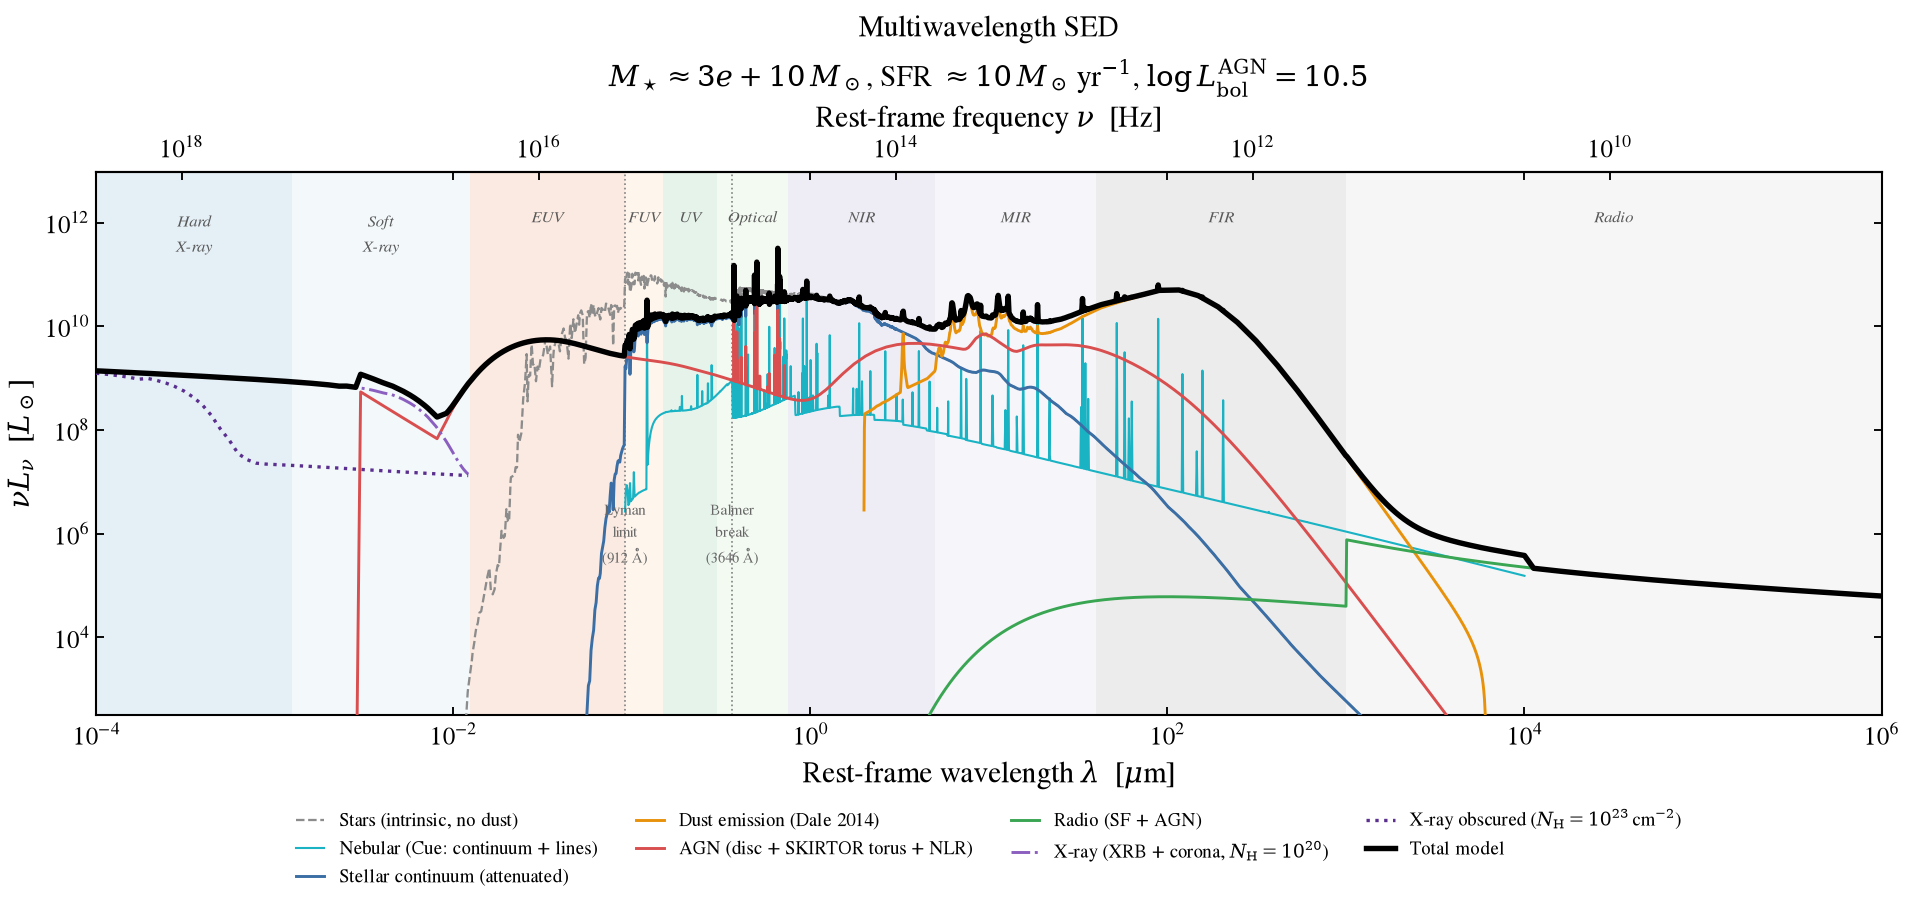

In [8]:
C_UM = 2.998e14  # speed of light in [µm Hz], for the λ → ν twin axis

money_shot = dict(
    # tau ≈ cosmic age at z = 0.1 puts the DPL on its rising shoulder, so
    # the current SFR is near peak (elevated, dusty main-sequence galaxy).
    sfh={
        "type": "dpl",
        "all_params": FIXED,
        "log_total_mass": 10.72,
        "alpha": 0.9,
        "beta": 2.7,
        "tau_gyr": 13.2,
    },
    dust_attenuation={
        "type": "two_component",
        "law": "calzetti",
        "all_params": FIXED,
        "tau_bc": 0.8,
        "tau_diff": 0.3,
        "slope": -0.4,
        # dale2014_cigale, not dale2014: this notebook also switches on a radio
        # block, and the plain Dale+2014 template embeds its own star-forming
        # radio synchrotron continuum out to 1.335 GHz. Running both double-counts
        # the radio continuum (~2x between ~1.34 and ~10 GHz), which #1983 made a
        # ConfigError. The _cigale variant has that tail stripped, per CIGALE
        # convention — the remedy that error itself prescribes.
    }, dust_emission={"type": "dale2014_cigale", "all_params": FIXED, "alpha_dale": 2.2},
    neb={"type": "cue", "all_params": FIXED},
    agn={
        "all_params": FIXED,  # every AGN block here is deliberately fixed (#1995)
        "disc": {"type": "multicolor", "all_params": FIXED, "log_lbol": 10.5},
        "torus": {"type": "skirtor", "all_params": FIXED, "tau_skirtor": 5.0, "torus_frac": 0.5},
        "nlr": {"type": "analytic", "all_params": FIXED},
        "blr": {"type": "none", "all_params": FIXED},
    },
    radio={"sf": {"type": "bell2003"}, "agn": {"type": "powerlaw"}, "all_params": FIXED},
    xray={"type": "simple", "all_params": FIXED},
    redshift=Fixed(0.1),
)

ms_model = SEDModel.build(ssp_data=ssp, observation=obs, **money_shot)
state = ms_model.predict_state(ms_model.spec.sample(jax.random.PRNGKey(0)))

wave_aa = np.asarray(state.wave)  # Å
wave_um = wave_aa / 1e4


def _comp(key):
    arr = state.derived.get(key)
    return None if arr is None else np.asarray(arr)


# νL_ν in solar luminosities so the y-axis matches the reference figure.
def nuLnu_lsun(lnu):
    return None if lnu is None else erg_per_s_to_lsun(nu_lnu(wave_aa, lnu))


lnu_age = _comp("lnu_age")
sed_stars = lnu_age.sum(axis=0) if lnu_age is not None else None
sed_total = np.asarray(state.sed_intrinsic)

# X-ray, with line-of-sight obscuration as a teaching point.
# ``state.derived["sed_xray"]`` is the full Yang+2020 / X-CIGALE X-ray —
# XRB + hot gas + AGN corona — at the default column N_H = 1e20 (the corona
# is driven by the AGN-published ``L_2500_intrinsic`` via the Just+2007 α_ox
# relation; #722/#746). It is already in the black total. To show how
# line-of-sight absorption carves the soft band, we recompute the X-ray at
# N_H = 1e23 with the model's own 2500 Å luminosity (Morrison & McCammon 1983
# + Wilms+2000 photoelectric + Compton). N_H is not yet a build-time
# parameter, so the obscured variant goes through the public ``tengri.xray`` API.
from tengri.xray import xray_total

_sfr = float(state.derived["sfr"])
_mstar = 10.0 ** float(state.derived["log_mstar"])
# Same l_2500 the X-ray component uses: intrinsic disc 2500 Å, falling back to
# the Hopkins+2007 bolometric correction when the disc value is unavailable.
_l2500 = float(state.derived.get("L_2500_intrinsic", 0.0))
if _l2500 <= 0.0:
    _l2500 = float(state.derived["L_agn_bol"]) / (5.15 * 1.199e15)
sed_xray_unobs = _comp("sed_xray")  # build's corona-complete X-ray (N_H=1e20)
sed_xray_obsc = np.asarray(
    xray_total(wave_aa, sfr=_sfr, stellar_mass=_mstar, l_2500_30deg=_l2500, log_nh=23.0)
)

# (sed, label, color, linestyle, linewidth) — drawn back-to-front.
CURVES = [
    (sed_stars, "Stars (intrinsic, no dust)", "0.55", "--", 1.1),
    (_comp("sed_nebular"), "Nebular (Cue: continuum + lines)", "#19b3c4", "-", 1.0),
    (_comp("sed_dust_attenuated"), "Stellar continuum (attenuated)", "#3a6ea5", "-", 1.4),
    (_comp("sed_dust_ir"), "Dust emission (Dale 2014)", "#e8920c", "-", 1.4),
    (_comp("sed_agn"), "AGN (disc + SKIRTOR torus + NLR)", "#d94f4f", "-", 1.4),
    (_comp("sed_radio"), "Radio (SF + AGN)", "#3aa653", "-", 1.4),
    (sed_xray_unobs, r"X-ray (XRB + corona, $N_{\rm H}=10^{20}$)", "#8a5fbf", "-.", 1.4),
    (sed_xray_obsc, r"X-ray obscured ($N_{\rm H}=10^{23}\,$cm$^{-2}$)", "#5a2f8f", ":", 1.6),
]

# Rest-frame wavelength regimes [µm]; pale alternating tints behind the SED.
BANDS = [
    ("Hard\nX-ray", 1e-4, 1.24e-3),
    ("Soft\nX-ray", 1.24e-3, 1.24e-2),
    ("EUV", 1.24e-2, 0.0912),
    ("FUV", 0.0912, 0.15),
    ("UV", 0.15, 0.30),
    ("Optical", 0.30, 0.75),
    ("NIR", 0.75, 5.0),
    ("MIR", 5.0, 40.0),
    ("FIR", 40.0, 1000.0),
    ("Radio", 1000.0, 1e6),
]

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xscale("log")
ax.set_yscale("log")

band_cmap = plt.colormaps["tab20c"]
for i, (name, w0, w1) in enumerate(BANDS):
    ax.axvspan(w0, w1, color=band_cmap(i / len(BANDS)), alpha=0.12, lw=0, zorder=0)
    ax.text(
        np.sqrt(w0 * w1),
        0.93,
        name,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=8,
        color="0.35",
        style="italic",
    )

for sed, label, color, ls, lw in CURVES:
    y = nuLnu_lsun(sed)
    if y is None:
        continue
    mask = np.asarray(sed) > 0
    if not np.any(mask):
        continue
    ax.plot(wave_um[mask], y[mask], color=color, ls=ls, lw=lw, label=label, zorder=3)

ax.plot(wave_um, nuLnu_lsun(sed_total), color="k", lw=2.6, label="Total model", zorder=4)

# Two rest-frame UV landmarks.
for lam_aa, txt in [(912.0, "Lyman\nlimit\n(912 Å)"), (3646.0, "Balmer\nbreak\n(3646 Å)")]:
    lam_um = lam_aa / 1e4
    ax.axvline(lam_um, color="0.5", ls=":", lw=0.8, zorder=1)
    ax.text(lam_um, 2e5, txt, fontsize=7, color="0.4", ha="center", va="bottom")

ax.set_xlim(1e-4, 1e6)
ymax = float(np.nanmax(nuLnu_lsun(sed_total)))
ax.set_ylim(ymax * 1e-9, ymax * 30)
ax.set_xlabel(r"Rest-frame wavelength $\lambda$  [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$  [$L_\odot$]")

# Twin frequency axis (ν = c / λ), sharing the log scale.
secax = ax.secondary_xaxis("top", functions=(lambda w: C_UM / w, lambda f: C_UM / f))
secax.set_xlabel(r"Rest-frame frequency $\nu$  [Hz]")

# Hero numbers, read back from the model.
m_star = 10.0 ** float(state.derived["log_mstar"])
sfr = float(state.derived["sfr"])
log_lagn = np.log10(erg_per_s_to_lsun(float(state.derived["L_agn_bol"])))
ax.set_title(
    "Multiwavelength SED\n"
    rf"$M_\star \approx {m_star:.0e}\,M_\odot$, "
    rf"SFR $\approx {sfr:.0f}\,M_\odot\,$yr$^{{-1}}$, "
    rf"$\log L_{{\rm bol}}^{{\rm AGN}} = {log_lagn:.1f}$"
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_anatomy_moneyshot.png", dpi=300, bbox_inches="tight")

Next: [`03_discovering_the_menu.py`](03_discovering_the_menu.py) shows
how to find every available variant from inside Python.